# Preprocessing
Resize images to 224×224, normalize pixel values, and collapse annotations into one row per image.

In [1]:
import json, os
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm

RAW_ROOT   = r'..\data\raw\CarDD_release\CarDD_COCO'
ANN_DIR    = os.path.join(RAW_ROOT, 'annotations')
PROC_ROOT  = r'..\data\processed'
IMG_OUT    = os.path.join(PROC_ROOT, 'images')

os.makedirs(IMG_OUT, exist_ok=True)
os.makedirs(PROC_ROOT, exist_ok=True)

TARGET_SIZE = (224, 224)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

SPLITS = ['train2017', 'val2017', 'test2017']
DAMAGE_TYPES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']

def load_coco(split):
    with open(os.path.join(ANN_DIR, f'instances_{split}.json')) as f:
        return json.load(f)

print('Setup complete.')

Setup complete.


## 1. Image Resizing — 1000×667 → 224×224

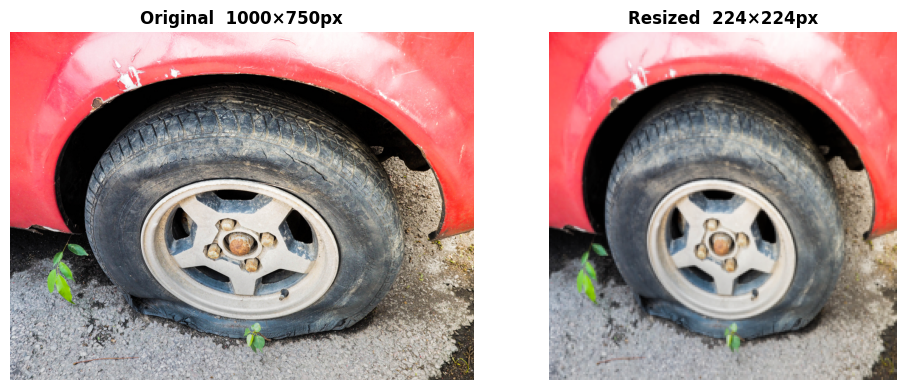

In [2]:
# Show before/after for one sample image
sample_path = os.path.join(RAW_ROOT, 'train2017', '000001.jpg')
original    = Image.open(sample_path).convert('RGB')
resized     = original.resize(TARGET_SIZE, Image.BILINEAR)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(original)
axes[0].set_title(f'Original  {original.size[0]}×{original.size[1]}px', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(resized)
axes[1].set_title(f'Resized  {resized.size[0]}×{resized.size[1]}px', fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [3]:
# Resize and save all images across all splits
total = 0
for split in SPLITS:
    split_in  = os.path.join(RAW_ROOT, split)
    split_out = os.path.join(IMG_OUT, split)
    os.makedirs(split_out, exist_ok=True)

    files = os.listdir(split_in)
    for fname in tqdm(files, desc=split):
        img = Image.open(os.path.join(split_in, fname)).convert('RGB')
        img = img.resize(TARGET_SIZE, Image.BILINEAR)
        img.save(os.path.join(split_out, fname))
    total += len(files)

print(f'\nDone. {total} images saved to {IMG_OUT}')

test2017: 100%|██████████| 374/374 [00:12<00:00, 31.04it/s]


Done. 4000 images saved to ..\data\processed\images


## 2. Annotations → Per-Image Feature Row

In [5]:
# Show raw annotations for one image before collapsing
data = load_coco('train2017')
cat_map = {c['id']: c['name'] for c in data['categories']}

ann_by_img = defaultdict(list)
for ann in data['annotations']:
    ann_by_img[ann['image_id']].append(ann)

# Pick an image with multiple annotations
sample_id = next(k for k, v in ann_by_img.items() if len(v) >= 3)

print(f'Image ID: {sample_id} — raw annotations ({len(ann_by_img[sample_id])} rows):')
print(f"{'ann_id':>7} {'category':<15} {'area':>9} {'bbox'}")
print('-' * 60)
for ann in ann_by_img[sample_id]:
    bbox = [round(v) for v in ann['bbox']]
    print(f"{ann['id']:>7} {cat_map[ann['category_id']]:<15} {ann['area']:>9.0f}  {bbox}")

Image ID: 8 — raw annotations (7 rows):
 ann_id category             area bbox
------------------------------------------------------------
      9 crack                3361  [308, 74, 49, 126]
     10 crack                 234  [389, 156, 16, 19]
     11 crack                1171  [450, 111, 40, 49]
     12 crack                2286  [515, 62, 78, 50]
     13 crack                2749  [741, 157, 97, 77]
     14 crack                 829  [855, 127, 32, 51]
     15 tire flat           81797  [363, 157, 260, 443]


In [6]:
def collapse_annotations(coco_data, split):
    cat_map  = {c['id']: c['name'] for c in coco_data['categories']}
    ann_by_img = defaultdict(list)
    for ann in coco_data['annotations']:
        ann_by_img[ann['image_id']].append(ann)

    rows = []
    for img in coco_data['images']:
        img_id = img['id']
        anns   = ann_by_img[img_id]

        # binary flags
        types_present = {cat_map[a['category_id']] for a in anns}
        flags = {f'has_{d.replace(" ", "_")}': int(d in types_present) for d in DAMAGE_TYPES}

        # total damage area
        total_damage_area = sum(a['area'] for a in anns)

        # damage count
        damage_count = len(anns)

        # dominant damage — type with largest single bbox area
        dominant = max(anns, key=lambda a: a['area'])
        dominant_damage = cat_map[dominant['category_id']]

        row = {
            'image_id':          img_id,
            'file_name':         img['file_name'],
            'split':             split,
            'damage_count':      damage_count,
            'total_damage_area': total_damage_area,
            'dominant_damage':   dominant_damage,
            **flags
        }
        rows.append(row)
    return rows

# Show the collapsed row for the same image
sample_rows = collapse_annotations(data, 'train2017')
sample_row  = next(r for r in sample_rows if r['image_id'] == sample_id)

print(f'\nSame image after collapsing into ONE row:')
for k, v in sample_row.items():
    print(f'  {k:<22} {v}')


Same image after collapsing into ONE row:
  image_id               8
  file_name              000008.jpg
  split                  train2017
  damage_count           7
  total_damage_area      92427.0
  dominant_damage        tire flat
  has_dent               0
  has_scratch            0
  has_crack              1
  has_glass_shatter      0
  has_lamp_broken        0
  has_tire_flat          1


In [7]:
# Process all splits and save CSV
all_rows = []
for split in SPLITS:
    coco = load_coco(split)
    rows = collapse_annotations(coco, split)
    all_rows.extend(rows)
    print(f'{split}: {len(rows)} rows')

df = pd.DataFrame(all_rows)

out_path = os.path.join(PROC_ROOT, 'annotations.csv')
df.to_csv(out_path, index=False)

print(f'\nSaved {len(df)} rows → {out_path}')
print(f'Columns: {list(df.columns)}')
df.head()

train2017: 2816 rows
val2017: 810 rows
test2017: 374 rows

Saved 4000 rows → ..\data\processed\annotations.csv
Columns: ['image_id', 'file_name', 'split', 'damage_count', 'total_damage_area', 'dominant_damage', 'has_dent', 'has_scratch', 'has_crack', 'has_glass_shatter', 'has_lamp_broken', 'has_tire_flat']


,image_id,file_name,split,damage_count,total_damage_area,dominant_damage,has_dent,has_scratch,has_crack,has_glass_shatter,has_lamp_broken,has_tire_flat
0,1,000001.jpg,train2017,2,312326.0,tire flat,0,1,0,0,0,1
1,2,000002.jpg,train2017,1,114126.0,tire flat,0,0,0,0,0,1
2,3,000003.jpg,train2017,1,299792.0,tire flat,0,0,0,0,0,1
3,4,000004.jpg,train2017,1,383763.0,tire flat,0,0,0,0,0,1
4,5,000005.jpg,train2017,1,258456.0,tire flat,0,0,0,0,0,1


In [8]:
# Quick sanity check
print('=== Sanity Check ===')
print(f'Total rows         : {len(df)}')
print(f'Splits             : {df["split"].value_counts().to_dict()}')
print(f'Damage count range : {df["damage_count"].min()} – {df["damage_count"].max()}')
print(f'Total damage area  : min={df["total_damage_area"].min():.0f}  max={df["total_damage_area"].max():.0f}')
print(f'Dominant damage    :\n{df["dominant_damage"].value_counts()}')

=== Sanity Check ===
Total rows         : 4000
Splits             : {'train2017': 2816, 'val2017': 810, 'test2017': 374}
Damage count range : 1 – 13
Total damage area  : min=539  max=851004
Dominant damage    :
dominant_damage
scratch          1305
dent             1155
glass shatter     659
lamp broken       490
tire flat         296
crack              95
Name: count, dtype: int64
